
========== BẢNG KẾT QUẢ ==========



,Metric,Teacher (zero-shot),Teacher (fine-tuned),No-KD (baseline),Seq-KD (Student),Word-KD (Student),FitNets (Student),Attention Transfer (Student),Combined Response+Feature (Student)
0,BLEU,0.0124,0.3178,0.2519,0.3416,0.3407,0.3110,0.3085,0.3410
1,ROUGE-L,0.2182,0.5070,0.4575,0.5187,0.5274,0.5051,0.4974,0.5327
2,CIDEr,0.0403,0.9632,0.7706,0.9998,1.0841,0.8821,0.7681,1.2053


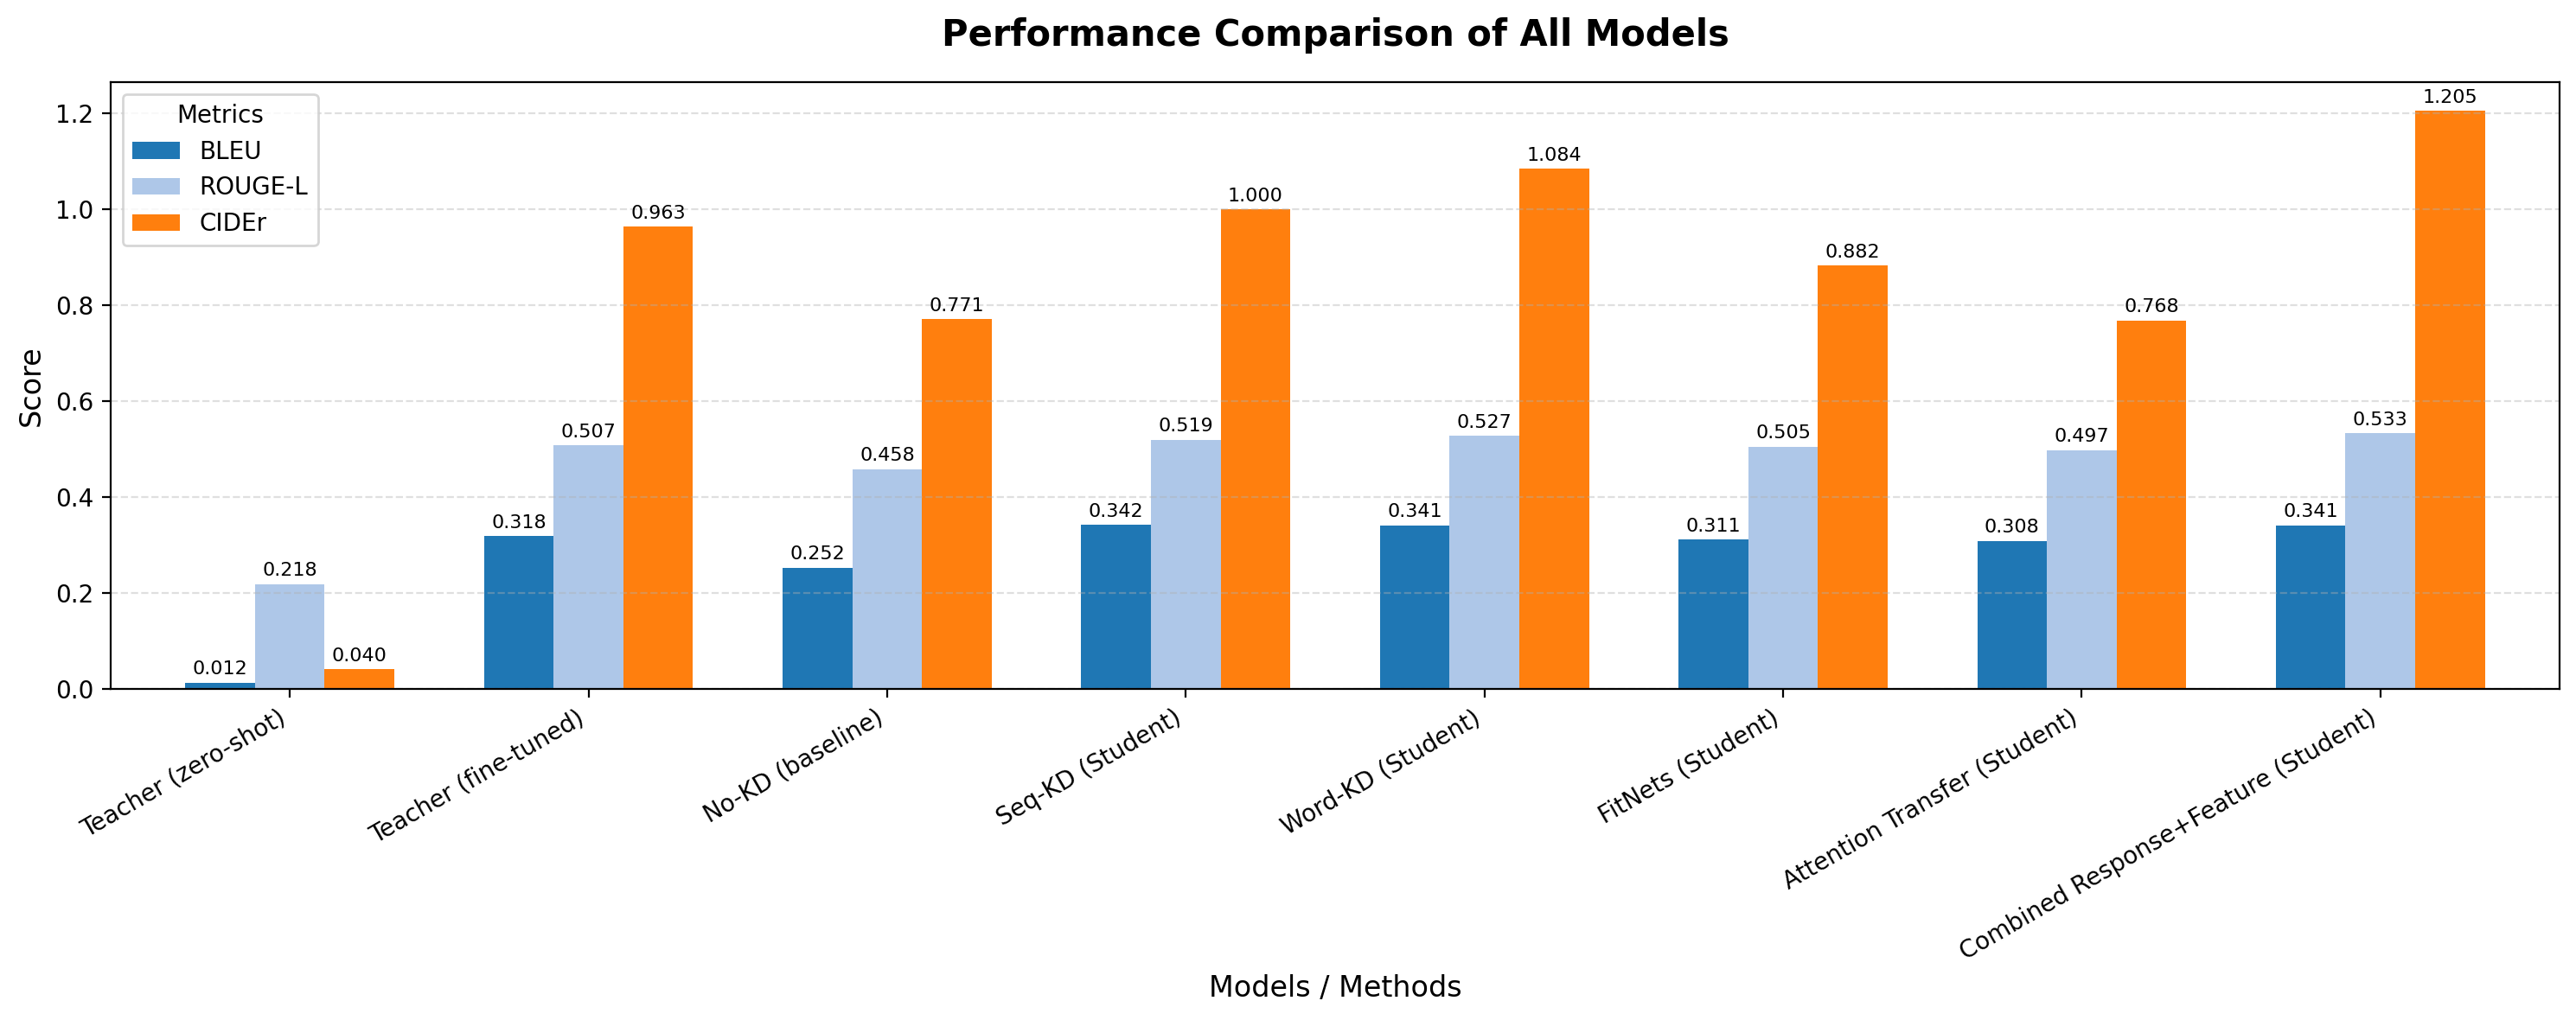

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# ==========================
# Đọc file kết quả
# ==========================
try:
    with open("results_file.json", "r", encoding="utf-8") as f:
        results = json.load(f)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'results_file.json'.")
    exit()

# ==========================
# Chuyển sang DataFrame
# ==========================
col_order = list(results.keys())

data = {"Metric": ["BLEU", "ROUGE-L", "CIDEr"]}

for col in col_order:
    bleu, rouge, cider = results[col]
    data[col] = [bleu, rouge, cider]

df_results = pd.DataFrame(data).round(4)

print("\n========== BẢNG KẾT QUẢ ==========\n")

try:
    display(df_results)
except NameError:
    print(df_results.to_string(index=False))

# ==========================
# Chuẩn bị dữ liệu vẽ
# ==========================
df_plot = df_results.set_index("Metric").T

# ==========================
# Vẽ biểu đồ
# ==========================
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)

colors = ["#1f77b4", "#aec7e8", "#ff7f0e"]

bars = df_plot.plot(
    kind="bar",
    width=0.7,
    color=colors,
    ax=ax
)

plt.title(
    "Performance Comparison of All Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Models / Methods", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(rotation=30, ha="right", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    title="Metrics",
    loc="upper left"
)

# ==========================
# Hiển thị giá trị trên cột
# ==========================
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()

# Lưu ảnh
plt.savefig("comparison_all_models.png", dpi=300, bbox_inches="tight")

plt.show()